All packages are installed in a venv with system passthrough, setup your own environment as you like.

In [1]:
# Imports

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import torch

# Force pandas to print to 3 decimal places
pd.set_option('display.float_format', lambda x: '%.3f' % x)

Housing dataset is from [here](https://www.kaggle.com/c/house-prices-advanced-regression-techniques), and the macroeconomic home value dataset is from [here](https://www.kaggle.com/datasets/sagarvarandekar/macroeconomic-factors-affecting-us-housing-prices)

In [2]:
# Import housing dataset and macro datasets

df_housing = pd.read_csv('housing.csv')
df_macro = pd.read_csv('macro.csv')

In [3]:
# - Repair housing dataset -

# This is a kaggle competition dataset, so there are plenty of designed issues to fix here

df_housing = df_housing.drop(columns=['Id'])

# Fix categorical NaN -> there is none (i.e. no pool)
categorical_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in categorical_cols:
    if col in df_housing.columns:
        df_housing[col] = df_housing[col].fillna('None')

# Fix numerical NaN -> missing data, fill w/ median to prevent outlier skew 
numerical_cols = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
for col in numerical_cols:
    if col in df_housing.columns:
        df_housing[col] = df_housing[col].fillna(df_housing[col].median())

# Drop cols where target pred. is missing somehow 
df_housing = df_housing.dropna(subset=['SalePrice'])

# Make mergekey using year_month using YrSold and MoSold, arbitrarily set day to 1 for conversion then make monthly
df_housing['year_month'] = pd.to_datetime(
    df_housing[['YrSold', 'MoSold']]
        .assign(DAY=1)
        .rename(columns={'YrSold': 'YEAR', 'MoSold': 'MONTH'})
).dt.to_period('M')

# There is ONE house without it's electrical, because it's categorical I'll just fill it with the mode
df_housing['Electrical'] = df_housing['Electrical'].fillna(df_housing['Electrical'].mode()[0])

# - Repair macro dataset - 

# Convert DATE to datetime (DD-MM-YYYY format), make matching year_month key
df_macro['DATE'] = pd.to_datetime(df_macro['DATE'], dayfirst=True)
df_macro['year_month'] = df_macro['DATE'].dt.to_period('M')

# Replace missing var with median
macro_missing_cols = ['MED HOUSEHOLD INCOME', '% SHARE OF WORKING POPULATION']
for col in macro_missing_cols:
    df_macro[col] = df_macro[col].fillna(df_macro[col].median())

In [4]:
# - Merge housing and macro datasets -

# Inner join, append economic data to each housing sale only if both match
# The actual overlap is only ~33% between datasets, would destroy analysis if we filled w/ median
df_merged = pd.merge(df_housing, df_macro, on='year_month', how='left')

# Remove merge key and the duplicated DATE
df_merged = df_merged.drop(columns=['year_month', 'DATE'])

print(df_merged.head())
print(df_merged.info())

   MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0          60       RL       65.000     8450   Pave  None      Reg   
1          20       RL       80.000     9600   Pave  None      Reg   
2          60       RL       68.000    11250   Pave  None      IR1   
3          70       RL       60.000     9550   Pave  None      IR1   
4          60       RL       84.000    14260   Pave  None      IR1   

  LandContour Utilities LotConfig  ... INFLATION(%)  \
0         Lvl    AllPub    Inside  ...        4.027   
1         Lvl    AllPub       FR2  ...        2.691   
2         Lvl    AllPub    Inside  ...        4.937   
3         Lvl    AllPub    Corner  ...        3.597   
4         Lvl    AllPub       FR2  ...        0.091   

  MORTGAGE INT. MONTHLY AVG(%) MED HOUSEHOLD INCOME CORP. BOND YIELD(%)  \
0                        5.918            50303.000               5.530   
1                        6.262            50233.000               5.470   
2                      

In [6]:
# Stats (mean, std, min, max)
print(df_merged.describe())

# Manually do var and med
num_col = df_merged.select_dtypes(include=['float', 'int'])
print()
print(f"Variance:\n{num_col.var()}")
print()
print(f"Median:\n{num_col.median()}")
print()

# Group saleprice by neighborhood
grp = df_merged.groupby("Neighborhood")['SalePrice'].agg(['mean', 'median', 'std', 'count'])

# Print sorted by median
print("\n--- Sale Price by Neighborhood ---")
print(grp.sort_values(by='median', ascending=False))

       MSSubClass  LotFrontage    LotArea  OverallQual  OverallCond  \
count    1460.000     1460.000   1460.000     1460.000     1460.000   
mean       56.897       69.864  10516.828        6.099        5.575   
std        42.301       22.028   9981.265        1.383        1.113   
min        20.000       21.000   1300.000        1.000        1.000   
25%        20.000       60.000   7553.500        5.000        5.000   
50%        50.000       69.000   9478.500        6.000        5.000   
75%        70.000       79.000  11601.500        7.000        6.000   
max       190.000      313.000 215245.000       10.000        9.000   

       YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  ...  \
count   1460.000      1460.000    1460.000    1460.000    1460.000  ...   
mean    1971.268      1984.866     103.117     443.640      46.549  ...   
std       30.203        20.645     180.731     456.098     161.319  ...   
min     1872.000      1950.000       0.000       0.000      

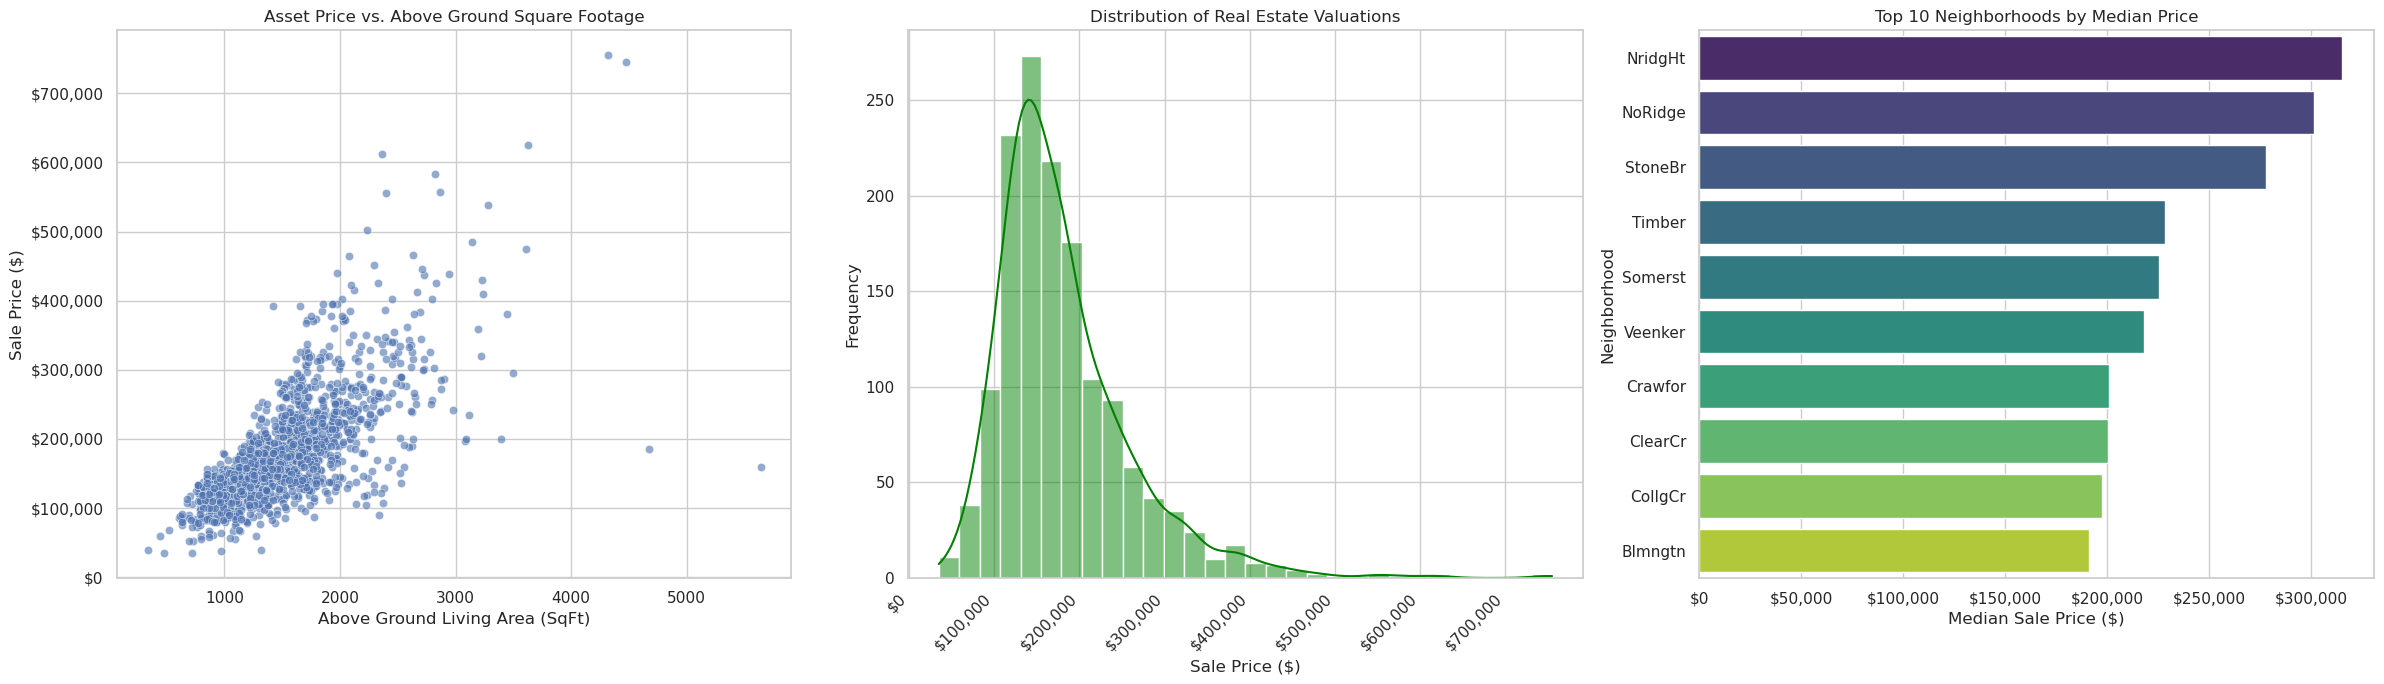

In [7]:
# Generic style
sns.set_theme(style="whitegrid")

# 3 subplts
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Money formatting stuff
price_fmt = StrMethodFormatter('${x:,.0f}')

# Plot 1: Scatter
sns.scatterplot(
    data=df_merged,
    x='GrLivArea',
    y='SalePrice',
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Asset Price vs. Above Ground Square Footage')
axes[0].set_xlabel('Above Ground Living Area (SqFt)')
axes[0].set_ylabel('Sale Price ($)')
axes[0].yaxis.set_major_formatter(price_fmt)

# Plot 2: Histrogram
sns.histplot(
    df_merged['SalePrice'],
    bins=30,
    kde=True,
    color='green',
    ax=axes[1]
)
axes[1].set_title('Distribution of Real Estate Valuations')
axes[1].set_xlabel('Sale Price ($)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(price_fmt)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right') # Rotate the x axis stuff

# Plot 3: Bar Plot
grp_sorted = grp.sort_values(by='median', ascending=False).reset_index()
sns.barplot(
    data=grp_sorted.head(10),
    x='median',
    y='Neighborhood',
    hue="Neighborhood",
    palette='viridis',
    legend=False,
    ax=axes[2]
)
axes[2].set_title('Top 10 Neighborhoods by Median Price')
axes[2].set_xlabel('Median Sale Price ($)')
axes[2].set_ylabel('Neighborhood')
axes[2].xaxis.set_major_formatter(price_fmt)

plt.tight_layout()
plt.show()

First model will be based on only physical factors, the physical featuers from the housing dataset, second model will use both physical and macroeconomic factors

In [8]:
# - Create training datasets for both models -

# It's simpler to just filter out all the columns I merged so I don't make a mistake missing a cleaning step or something
macro_cols = ['UNRATE(%)', 'CONSUMER CONF INDEX', 'PPI-CONST MAT.', 'CPIALLITEMS', 
              'INFLATION(%)', 'MORTGAGE INT. MONTHLY AVG(%)', 'MED HOUSEHOLD INCOME', 
              'CORP. BOND YIELD(%)', 'MONTHLY HOME SUPPLY', '% SHARE OF WORKING POPULATION', 
              'GDP PER CAPITA', 'QUARTERLY REAL GDP', 'QUARTERLY GDP GROWTH RATE (%)', 'CSUSHPISA']

df_physical = df_merged.drop(columns=macro_cols)
df_enhanced = df_merged.copy()

# One-hot encoding (categorical -> binary thing)
df_physical_enc = pd.get_dummies(df_physical, drop_first=True)
df_enhanced_enc = pd.get_dummies(df_enhanced, drop_first=True)

In [9]:
# - Model target + features - 

# Split into input and outputs for set A
X_a = df_physical_enc.drop(columns=['SalePrice'])
Y_a = df_physical_enc['SalePrice']

# 80% for training, 20% for testing
X_train_a, X_test_a, Y_train_a, Y_test_a = train_test_split(
    X_a, Y_a, test_size=0.2, random_state=1
)

# Split into input and outputs for set B
X_b = df_enhanced_enc.drop(columns=['SalePrice'])
Y_b = df_enhanced_enc['SalePrice']

# Same training/testing split, same random state so exact same houses are used in both experiments
X_train_b, X_test_b, Y_train_b, Y_test_b = train_test_split(
    X_b, Y_b, test_size=0.2, random_state=1
)

print(f"Set A (Physical) features: {X_train_a.shape[1]}")
print(f"Set B (Physical + Macro) features: {X_train_b.shape[1]}")
print(f"Testing on {len(X_test_a)} houses.")

Set A (Physical) features: 259
Set B (Physical + Macro) features: 273
Testing on 292 houses.


Baseline linear regression model for both Set A and Set B:

In [14]:
# Train lin reg. on set A

lr_model_a = LinearRegression()
lr_model_a.fit(X_train_a, Y_train_a)
predictions_a = lr_model_a.predict(X_test_a)

r2_a = r2_score(Y_test_a, predictions_a)
mse_a = mean_squared_error(Y_test_a, predictions_a)

print("LINEAR MODEL A (Physical Only)")
print(f"R-Squared: {r2_a:.4f}")
print()

# Repeat for set B

lr_model_b = LinearRegression()
lr_model_b.fit(X_train_b, Y_train_b)
predictions_b = lr_model_b.predict(X_test_b)

r2_b = r2_score(Y_test_b, predictions_b)
mse_b = mean_squared_error(Y_test_b, predictions_b)

print("LINEAR MODEL B (Physical + Macro) ---")
print(f"R-Squared: {r2_b:.4f}")

print()
print("Macro coefficients (Model B)")
for col in macro_cols:
    if col in X_train_b.columns:
        idx = X_train_b.columns.get_loc(col)
        coef = lr_model_b.coef_[idx]
        print(f"{col}: ${coef:,.2f}")

LINEAR MODEL A (Physical Only)
R-Squared: 0.6260

LINEAR MODEL B (Physical + Macro) ---
R-Squared: 0.6342

Macro coefficients (Model B)
UNRATE(%): $3,299.77
CONSUMER CONF INDEX: $-42.25
PPI-CONST MAT.: $673.97
CPIALLITEMS: $-1,102.04
INFLATION(%): $-194.86
MORTGAGE INT. MONTHLY AVG(%): $1,722.46
MED HOUSEHOLD INCOME: $-1.75
CORP. BOND YIELD(%): $1,306.13
MONTHLY HOME SUPPLY: $-1,144.62
% SHARE OF WORKING POPULATION: $62,478.84
GDP PER CAPITA: $-12.97
QUARTERLY REAL GDP: $55.32
QUARTERLY GDP GROWTH RATE (%): $-443.49
CSUSHPISA: $-3,878.61
